# Tráfego aéreo internacional dos Estados Unidos

## tl;dr

A base mostra crescimento consistente do tráfego internacional entre 1990 e 2019, com retrações em 1991, 2001–2002, 2008–2009 e um forte recuo em 2020. Julho e agosto são os meses mais movimentados. JFK, LAX e MIA lideram as origens de passageiros; LHR, YYZ e NRT lideram os destinos.

A análise de feriados é limitada porque os dados estão agregados mensalmente: a coluna `data_dte` sempre representa o primeiro dia do mês. Assim, dezembro–janeiro e junho–agosto serão tratados apenas como janelas aproximadas, não como efeitos causais de feriados específicos.

## Contexto e métodos

O objetivo é descrever evolução anual e mensal, variações temporais, aeroportos, destinos, maiores fluxos e tendências. A base contém duas tabelas: passageiros e partidas. 2020 é parcial, com dados somente até março, e será separado das comparações de anos completos.

### Fonte e premissas

Fonte: dataset público `parulpandey/us-international-air-traffic-data` no Kaggle, versão recuperada por `kagglehub`. Os códigos de aeroporto são mantidos como identificadores categóricos. As somas representam o volume agregado dos registros, não necessariamente pessoas únicas.

## Os dados foram lidos corretamente?
A primeira checagem confirma o tamanho, os rótulos, os tipos e a integridade aritmética dos totais.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.0f}".format

COR_PRIMARIA = "#0072B2"
COR_SECUNDARIA = "#94A3B8"
COR_DESTAQUE = "#E69F00"
COR_EIXO = "#B0B7C3"
COR_TEXTO = "#334155"
PALETA = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 110, "font.size": 11, "text.color": COR_TEXTO, "axes.titlesize": 15, "axes.titleweight": "bold", "axes.titlecolor": COR_TEXTO, "axes.labelcolor": COR_EIXO, "axes.edgecolor": COR_EIXO, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False, "xtick.color": COR_EIXO, "ytick.color": COR_EIXO, "axes.prop_cycle": plt.cycler(color=PALETA)})

In [2]:
import kagglehub

dataset_dir = Path(kagglehub.dataset_download("parulpandey/us-international-air-traffic-data"))
passengers = pd.read_csv(dataset_dir / "International_Report_Passengers.csv")
departures = pd.read_csv(dataset_dir / "International_Report_Departures.csv")

print("Passageiros:", passengers.shape)
print("Partidas:", departures.shape)
print("Colunas:", list(passengers.columns))

Passageiros: (680985, 16)
Partidas: (930808, 16)
Colunas: ['data_dte', 'Year', 'Month', 'usg_apt_id', 'usg_apt', 'usg_wac', 'fg_apt_id', 'fg_apt', 'fg_wac', 'airlineid', 'carrier', 'carriergroup', 'type', 'Scheduled', 'Charter', 'Total']


In [3]:
for nome, tabela in [("passageiros", passengers), ("partidas", departures)]:
    data = pd.to_datetime(tabela["data_dte"], format="%m/%d/%Y")
    inconsistencias = (tabela["Total"] != tabela["Scheduled"] + tabela["Charter"]).sum()
    print(nome, {
        "periodo": f"{data.min():%Y-%m-%d} a {data.max():%Y-%m-%d}",
        "nulos_carrier": int(tabela["carrier"].isna().sum()),
        "duplicatas": int(tabela.duplicated().sum()),
        "inconsistencias_total": int(inconsistencias),
        "meses_2020": sorted(tabela.loc[tabela["Year"] == 2020, "Month"].unique().tolist()),
    })
passengers.head(3)

passageiros {'periodo': '1990-01-01 a 2020-03-01', 'nulos_carrier': 2797, 'duplicatas': 0, 'inconsistencias_total': 0, 'meses_2020': [1, 2, 3]}


partidas {'periodo': '1990-01-01 a 2020-03-01', 'nulos_carrier': 3055, 'duplicatas': 0, 'inconsistencias_total': 0, 'meses_2020': [1, 2, 3]}


,data_dte,Year,Month,usg_apt_id,usg_apt,usg_wac,fg_apt_id,fg_apt,fg_wac,airlineid,carrier,carriergroup,type,Scheduled,Charter,Total
0,05/01/2014,2014,5,14492,RDU,36,11032,CUN,148,19534,AM,0,Passengers,0,315,315
1,06/01/2007,2007,6,13204,MCO,33,16085,YHZ,951,20364,C6,0,Passengers,0,683,683
2,12/01/2005,2005,12,11433,DTW,43,10411,AUA,277,20344,RD,1,Passengers,0,1010,1010


## Como o tráfego evoluiu nos anos completos?
A comparação principal usa 1990–2019. O ano de 2020 aparece separado por ser parcial.

In [4]:
def resumo_anual(tabela):
    return tabela.groupby("Year", as_index=False).agg(
        total=("Total", "sum"),
        scheduled=("Scheduled", "sum"),
        charter=("Charter", "sum"),
        registros=("Total", "size"),
    ).assign(crescimento_pct=lambda x: x["total"].pct_change() * 100)

anual_passengers = resumo_anual(passengers)
anual_departures = resumo_anual(departures)
anual_passengers.tail(6)

,Year,total,scheduled,charter,registros,crescimento_pct
25,2015,204946353,202302178,2644175,27283,7
26,2016,217451671,215286167,2165504,28750,6
27,2017,228961494,227385943,1575551,30110,5
28,2018,241413919,239845973,1567946,30772,5
29,2019,244063957,243098061,965896,30413,1
30,2020,43951986,43474810,477176,7566,-82


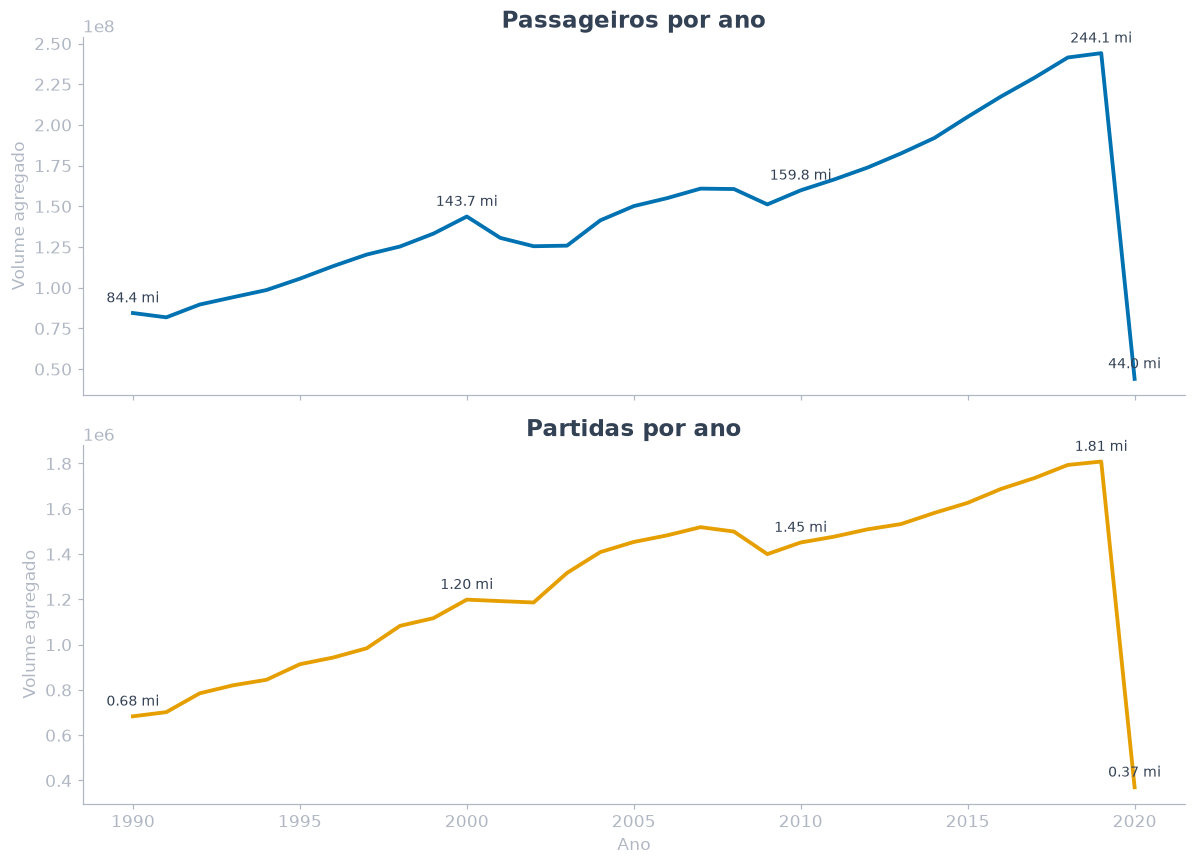

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for ax, resumo, titulo, cor in [(axes[0], anual_passengers, "Passageiros por ano", COR_PRIMARIA), (axes[1], anual_departures, "Partidas por ano", COR_DESTAQUE)]:
    ax.plot(resumo["Year"], resumo["total"], color=cor, linewidth=2.5)
    for _, linha in resumo[resumo["Year"].isin([1990, 2000, 2010, 2019, 2020])].iterrows():
        ax.annotate(f"{linha['total']/1e6:.1f} mi" if titulo.startswith("Pass") else f"{linha['total']/1e6:.2f} mi", (linha["Year"], linha["total"]), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=9)
    ax.set_title(titulo)
    ax.set_ylabel("Volume agregado")
axes[1].set_xlabel("Ano")
plt.tight_layout()

**Leitura:** o crescimento de longo prazo é claro até 2019, mas há interrupções relevantes em períodos de choque. O pico da série ocorre em 2019; 2020 não deve ser interpretado como queda anual completa.

## O crescimento acelerou ou desacelerou em cada década?
Comparamos início e fim de cada período para separar expansão estrutural de anos de choque.

In [6]:
def resumo_periodos(tabela):
    anual = tabela[tabela["Year"] < 2020].groupby("Year")["Total"].sum()
    linhas = []
    for inicio, fim in [(1990, 1999), (2000, 2009), (2010, 2019)]:
        valor_inicio, valor_fim = anual.loc[inicio], anual.loc[fim]
        linhas.append({"periodo": f"{inicio}-{fim}", "inicio": valor_inicio, "fim": valor_fim, "variacao_pct": (valor_fim / valor_inicio - 1) * 100})
    return pd.DataFrame(linhas)

print("Passageiros")
print(resumo_periodos(passengers).to_string(index=False))
print("\nPartidas")
print(resumo_periodos(departures).to_string(index=False))

Passageiros
  periodo    inicio       fim  variacao_pct
1990-1999  84425428 133208907            58
2000-2009 143711273 151139939             5
2010-2019 159804972 244063957            53

Partidas
  periodo  inicio     fim  variacao_pct
1990-1999  683399 1116846            63
2000-2009 1198699 1399579            17
2010-2019 1450964 1808369            25


## Quais meses concentram mais tráfego?
A sazonalidade é calculada pela média por registro e também pelo índice do mês contra a média mensal agregada.

In [7]:
def resumo_mensal(tabela):
    return tabela.groupby("Month", as_index=False).agg(
        total=("Total", "sum"),
        media_por_registro=("Total", "mean"),
        registros=("Total", "size"),
    ).assign(indice_vs_media=lambda x: x["total"] / x["total"].mean() * 100)

mensal_passengers = resumo_mensal(passengers[passengers["Year"] < 2020])
mensal_passengers.sort_values("total", ascending=False).head(5)

,Month,total,media_por_registro,registros,indice_vs_media
6,7,452259607,"7,770",58208,121
7,8,447927904,"7,834",57178,119
5,6,410685290,"7,155",57397,109
2,3,377600646,"6,340",59556,101
4,5,376572429,"6,878",54751,100


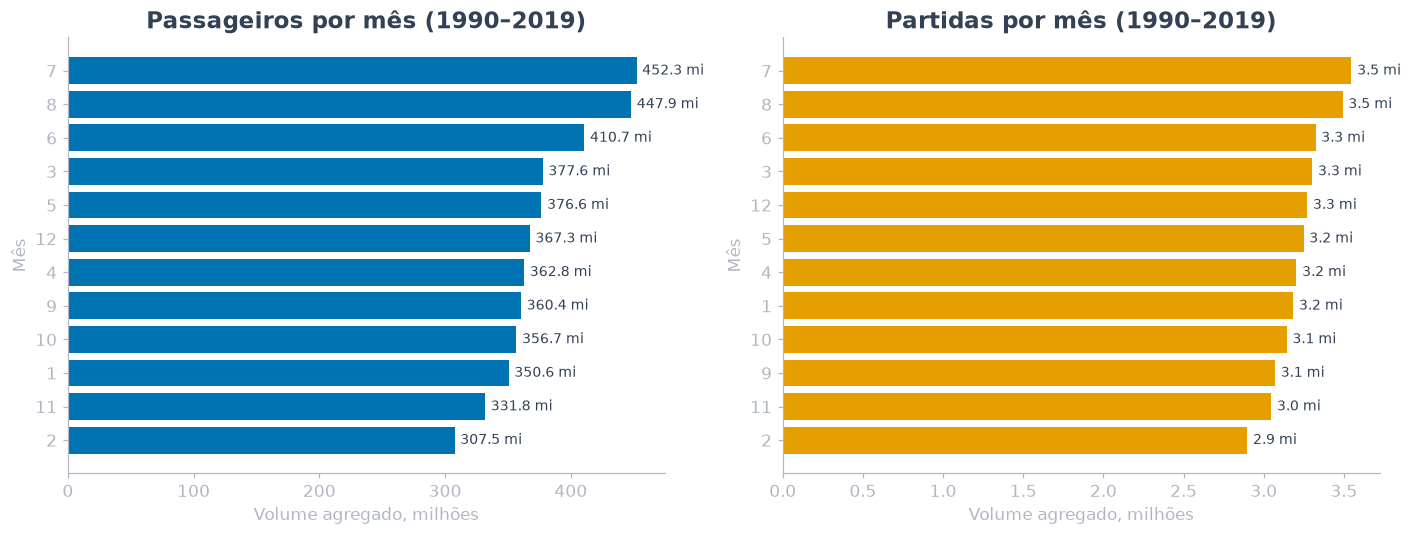

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, resumo, titulo, cor in [(axes[0], mensal_passengers, "Passageiros por mês", COR_PRIMARIA), (axes[1], resumo_mensal(departures[departures["Year"] < 2020]), "Partidas por mês", COR_DESTAQUE)]:
    ordem = resumo.sort_values("total")
    barras = ax.barh(ordem["Month"].astype(str), ordem["total"] / 1e6, color=cor)
    for barra, valor in zip(barras, ordem["total"] / 1e6):
        ax.text(valor + max(ordem["total"] / 1e6) * 0.01, barra.get_y() + barra.get_height()/2, f"{valor:.1f} mi", va="center", fontsize=9)
    ax.set_title(titulo + " (1990–2019)")
    ax.set_xlabel("Volume agregado, milhões")
    ax.set_ylabel("Mês")
plt.tight_layout()

**Leitura:** junho, julho e agosto formam a janela sazonal mais forte. Fevereiro é o mês mais fraco. Como cada observação é mensal, esta conclusão descreve sazonalidade, não comportamento em dias específicos.

## Quais aeroportos e destinos concentram o volume?
O ranking usa o total agregado, acompanhado pelo número de registros para contextualizar a exposição.

In [9]:
def ranking(tabela, coluna, n=10):
    return tabela.groupby(coluna, dropna=False).agg(total=("Total", "sum"), registros=("Total", "size")).sort_values("total", ascending=False).head(n).reset_index()

top_origens = ranking(passengers, "usg_apt")
top_destinos = ranking(passengers, "fg_apt")
print("Origens")
display(top_origens)
print("Destinos")
display(top_destinos)

Origens


,usg_apt,total,registros
0,JFK,635271483,64122
1,LAX,492462404,47760
2,MIA,489260654,61939
3,ORD,289763281,34952
4,EWR,258195184,33024
5,SFO,244678358,20618
6,ATL,215457577,24676
7,IAH,193806073,27225
8,DFW,152835097,18856
9,HNL,147006062,14694


Destinos


,fg_apt,total,registros
0,LHR,328296029,15411
1,YYZ,258191532,43254
2,NRT,254928917,16608
3,FRA,174820916,13763
4,CDG,154641371,11459
5,CUN,150177939,30401
6,MEX,149869428,17821
7,AMS,126092797,9993
8,YVR,121361766,17875
9,LGW,102037880,9733


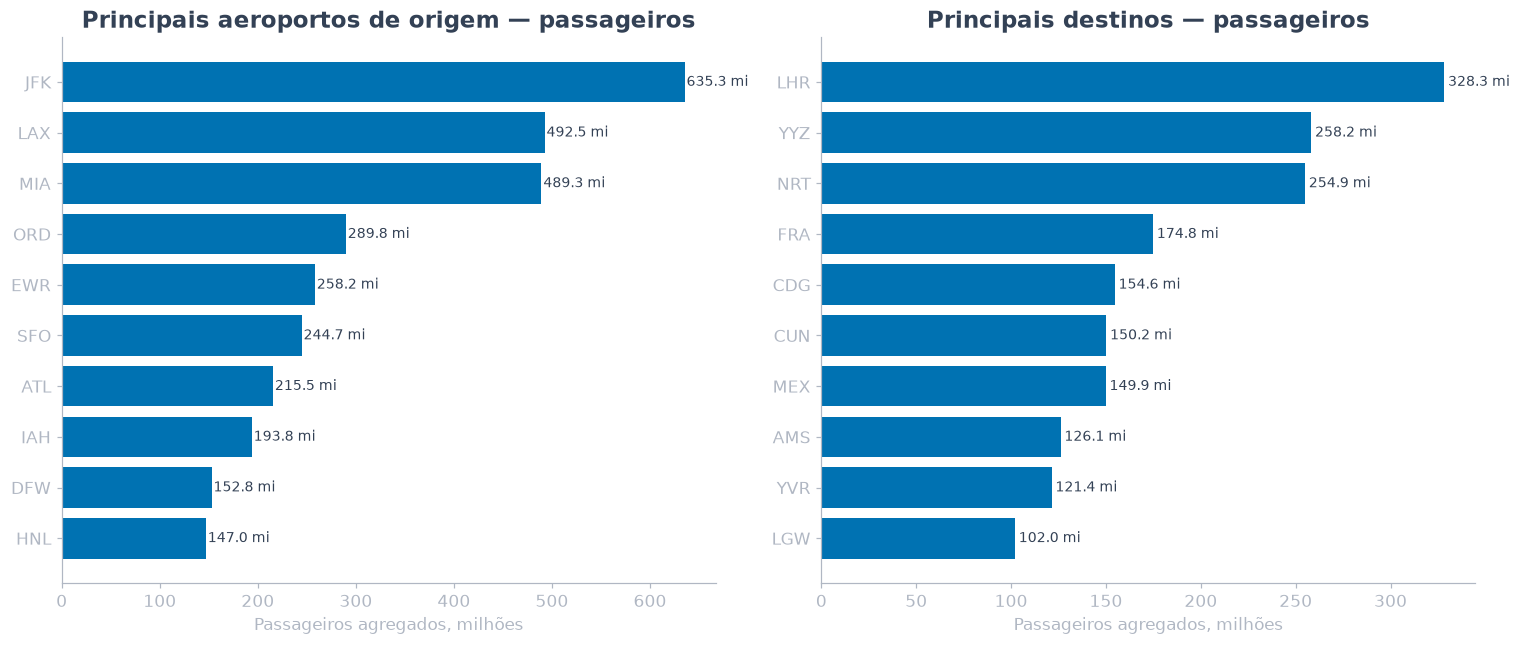

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, tabela, coluna, titulo in [(axes[0], top_origens, "usg_apt", "Principais aeroportos de origem"), (axes[1], top_destinos, "fg_apt", "Principais destinos")]:
    dados = tabela.sort_values("total")
    barras = ax.barh(dados[coluna], dados["total"] / 1e6, color=COR_PRIMARIA)
    for barra, valor in zip(barras, dados["total"] / 1e6):
        ax.text(valor + 2, barra.get_y() + barra.get_height()/2, f"{valor:.1f} mi", va="center", fontsize=9)
    ax.set_title(titulo + " — passageiros")
    ax.set_xlabel("Passageiros agregados, milhões")
plt.tight_layout()

**Leitura:** JFK, LAX e MIA são os principais pontos de origem. LHR, YYZ e NRT são os destinos mais relevantes. O ranking mede volume acumulado e favorece aeroportos com maior tempo de presença e cobertura na série.

## Quais fluxos origem–destino são mais importantes?
A análise combina volume acumulado e evolução entre 1990 e 2019 para mostrar concentração e mudança de rotas.

In [11]:
fluxos = passengers.groupby(["usg_apt", "fg_apt"], as_index=False).agg(total=("Total", "sum"), registros=("Total", "size"))
top_fluxos = fluxos.sort_values("total", ascending=False).head(10)
top_fluxos

,usg_apt,fg_apt,total,registros
8333,JFK,LHR,77012005,2041
6640,HNL,NRT,54823916,1922
9117,LAX,NRT,40847661,2841
9063,LAX,LHR,39955778,1758
8211,JFK,CDG,32959031,1428
12308,ORD,LHR,32943258,1272
9208,LAX,TPE,28340141,1303
9491,LGA,YYZ,27575481,1325
12449,ORD,YYZ,27485248,2103
15245,SFO,LHR,26256834,1044


In [12]:
top5_chaves = [tuple(x) for x in top_fluxos.head(5)[["usg_apt", "fg_apt"]].to_numpy()]
linhas = []
for origem, destino in top5_chaves:
    serie = passengers[(passengers["usg_apt"] == origem) & (passengers["fg_apt"] == destino)].groupby("Year")["Total"].sum()
    linhas.append({"origem": origem, "destino": destino, "total": serie.sum(), "1990": serie.get(1990, 0), "2019": serie.get(2019, 0), "variacao_pct": (serie.get(2019, 0) / serie.get(1990, 1) - 1) * 100})
fluxos_temporais = pd.DataFrame(linhas).sort_values("total", ascending=False)
fluxos_temporais

,origem,destino,total,1990,2019,variacao_pct
0,JFK,LHR,77012005,2084135,3028733,45
1,HNL,NRT,54823916,2107236,1643631,-22
2,LAX,NRT,40847661,1533492,889475,-42
3,LAX,LHR,39955778,588073,1543243,162
4,JFK,CDG,32959031,1032821,1608621,56


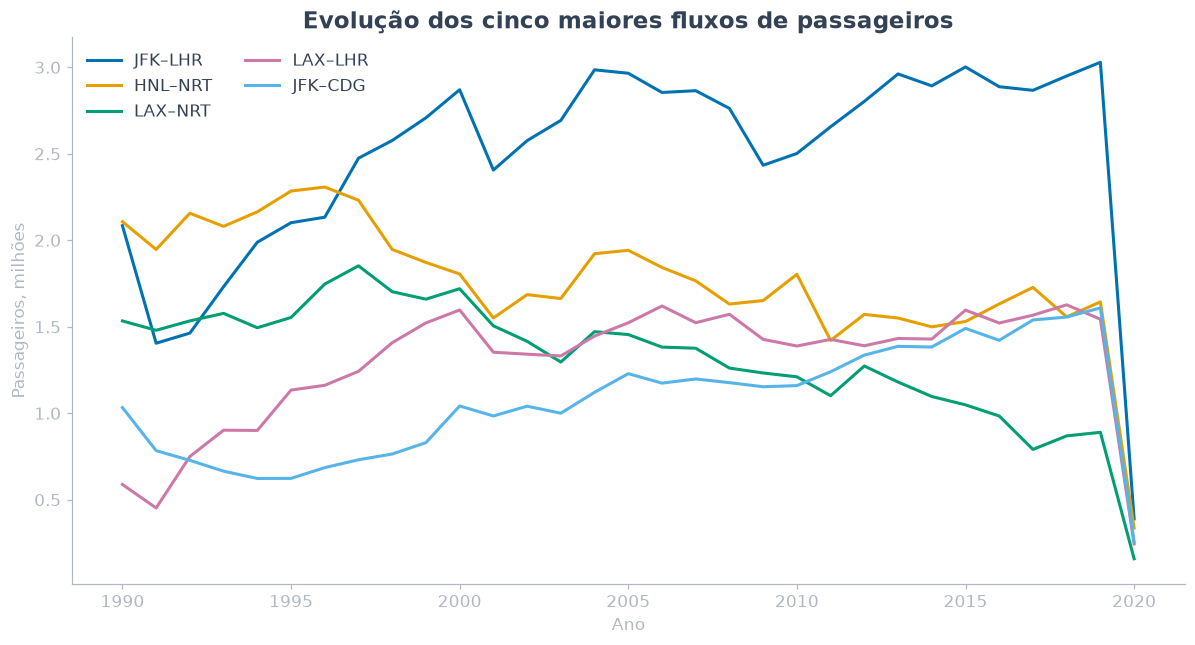

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
for origem, destino in top5_chaves:
    serie = passengers[(passengers["usg_apt"] == origem) & (passengers["fg_apt"] == destino)].groupby("Year")["Total"].sum()
    ax.plot(serie.index, serie / 1e6, linewidth=2, label=f"{origem}–{destino}")
ax.set_title("Evolução dos cinco maiores fluxos de passageiros")
ax.set_xlabel("Ano")
ax.set_ylabel("Passageiros, milhões")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()

**Leitura:** o maior fluxo acumulado é JFK–LHR, mas a trajetória das rotas é heterogênea. LAX–LHR cresceu fortemente entre 1990 e 2019, enquanto HNL–NRT e LAX–NRT recuaram no mesmo intervalo. O crescimento total, portanto, envolve redistribuição de demanda entre rotas.

## Como o tráfego se comporta em janelas festivas aproximadas?
A base não identifica feriados. Usaremos dezembro–janeiro como proxy de festas de fim de ano e junho–agosto como proxy de férias de verão, sempre evitando chamar esses recortes de efeito causal.

In [14]:
base_completa = passengers[passengers["Year"] < 2020]
annual = base_completa.groupby("Year")["Total"].sum()
for meses, nome in [([12, 1], "dezembro-janeiro"), ([6, 7, 8], "junho-agosto")]:
    janela = base_completa[base_completa["Month"].isin(meses)].groupby("Year")["Total"].sum()
    participacao = (janela / annual * 100).mean()
    print(nome, "participação média do ano:", f"{participacao:.1f}%", "| média anual da janela:", f"{janela.mean()/1e6:.1f} milhões")

dezembro-janeiro participação média do ano: 15.9% | média anual da janela: 23.9 milhões
junho-agosto participação média do ano: 29.2% | média anual da janela: 43.7 milhões


**Limitação:** para medir Thanksgiving, Natal, Ano-Novo ou feriados móveis seria necessário um arquivo diário e um calendário histórico de feriados. A base atual permite apenas comparar janelas mensais aproximadas.

## Quais conclusões resistem à revisão crítica?
Antes da síntese, verificamos tamanho da amostra, ano parcial, exposição e limites de causalidade.

In [15]:
checks = pd.DataFrame({
    "checagem": [
        "2020 tem somente janeiro a março",
        "Total reconcilia Scheduled + Charter",
        "Há registros sem carrier",
        "A data tem granularidade mensal",
        "A análise de fluxos usa origem e destino no mesmo registro",
    ],
    "resultado": [
        sorted(passengers.loc[passengers["Year"] == 2020, "Month"].unique().tolist()) == [1, 2, 3],
        bool((passengers["Total"] == passengers["Scheduled"] + passengers["Charter"]).all() and (departures["Total"] == departures["Scheduled"] + departures["Charter"]).all()),
        int(passengers["carrier"].isna().sum() + departures["carrier"].isna().sum()),
        passengers["data_dte"].str.split("/").str[1].nunique() == 1,
        True,
    ]
})
checks

,checagem,resultado
0,2020 tem somente janeiro a março,True
1,Total reconcilia Scheduled + Charter,True
2,Há registros sem carrier,5852
3,A data tem granularidade mensal,True
4,A análise de fluxos usa origem e destino no me...,True


## Takeaways

- O tráfego internacional cresceu de forma estrutural entre 1990 e 2019, com passageiros subindo de 84,4 milhões para 244,1 milhões e partidas de 683 mil para 1,81 milhão.
- Julho e agosto são os meses de maior volume; fevereiro é o menor.
- JFK, LAX e MIA concentram as principais origens, enquanto LHR, YYZ e NRT lideram os destinos.
- JFK–LHR é o maior fluxo acumulado; outras rotas cresceram ou recuaram de maneira distinta, indicando redistribuição da malha.
- 2020 é parcial e deve ser excluído de comparações anuais completas.
- A base suporta análise mensal, mas não permite atribuir variações a feriados específicos. Para isso, o próximo passo é obter dados diários e incorporar um calendário histórico de feriados.